In [21]:
"""
Breast Cancer Prediction with KNN
Author: [Eugen]
Description: Predict whether a breast tumor is malignant or benign using KNN
"""
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
 
# Load the breast cancer dataset
print("Loading breast cancer dataset...")
cancer_data = load_breast_cancer()
 
# The dataset is a Bunch object with 'data', 'target', 'feature_names', etc.
print(f"\nDataset type: {type(cancer_data)}")
print(f"Number of samples: {len(cancer_data.data)}")
print(f"Number of features: {len(cancer_data.feature_names)}")
print(f"Target classes: {cancer_data.target_names}")
 
# Convert to DataFrame for easier manipulation
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target
 
print("\nFirst few rows:")
print(df.head())
 
print("\nDataset info:")
print(df.info())
 
print("\nTarget distribution:")
print(df['target'].value_counts())
print(f"Malignant (1): {(df['target'] == 1).sum()}")

print(f"Benign (0): {(df['target'] == 0).sum()}")

Loading breast cancer dataset...

Dataset type: <class 'sklearn.utils._bunch.Bunch'>
Number of samples: 569
Number of features: 30
Target classes: ['malignant' 'benign']

First few rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520

In [12]:

# X = all the columns the model uses to make predictions (the 30 measurements)
# y = the answer column (0 = benign, 1 = malignant) - what we want to predict
X = df.drop('target', axis=1)  # drop the target column, keep everything else
y = df['target']               # keep only the target column

# Check the shapes to make sure it worked
# X should be (569, 30) = 569 patients, 30 features each
# y should be (569,) = 569 answers
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


# Why? The model learns from training data, then we test it on unseen data
# to see if it actually learned patterns vs just memorizing
# stratify=y keeps the same ratio of benign/malignant in both sets
# random_state=42 makes the split identical every time you run it
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing, 80% for training
    random_state=42,     # reproducibility - same split every run
    stratify=y           # keep class balance equal in both sets
)

# STEP 2: Verify the split worked correctly
# We want to confirm how many samples ended up in each set
print("\n" + "="*50)
print("DATA SPLIT")
print("="*50)
print(f"Training set size: {X_train.shape[0]} samples")   # should be ~455 (80%)
print(f"Test set size: {X_test.shape[0]} samples")         # should be ~114 (20%)
print(f"Training features: {X_train.shape[1]}")            # should be 30
print(f"Test features: {X_test.shape[1]}")                 # should be 30


# Because of stratify=y, the percentage of benign vs malignant
# should be roughly the same in training and testing
# This matters because if all malignant cases ended up in one set,
# the model would never learn to detect them
print("\nTraining set target distribution:")
print(y_train.value_counts())
print(f"  Benign (0): {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Malignant (1): {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")

print("\nTest set target distribution:")
print(y_test.value_counts())
print(f"  Benign (0): {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Malignant (1): {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")

Features shape: (569, 30)
Target shape: (569,)

DATA SPLIT
Training set size: 455 samples
Test set size: 114 samples
Training features: 30
Test features: 30

Training set target distribution:
target
1    285
0    170
Name: count, dtype: int64
  Benign (0): 170 (37.4%)
  Malignant (1): 285 (62.6%)

Test set target distribution:
target
1    72
0    42
Name: count, dtype: int64
  Benign (0): 42 (36.8%)
  Malignant (1): 72 (63.2%)


In [13]:
# Create KNN classifier
# n_neighbors=5 means the model will look at the 5 nearest neighbors to make a prediction

# STEP 4: Train the KNN Model
# KNN = K-Nearest Neighbors
# It looks at the 5 closest data points to a new sample
# and predicts based on what the majority of those 5 are
# Think of it like: "who are my 5 nearest neighbors? Most are benign? Then I'm probably benign too"

 
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
 
print("KNN classifier trained successfully!")
print(f"Number of neighbors (k): {knn.n_neighbors}")
 
#Step 5

# Make predictions
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)
 
print(f"\nTraining predictions: {len(y_train_pred)}")
print(f"Test predictions: {len(y_test_pred)}")

KNN classifier trained successfully!
Number of neighbors (k): 5

Training predictions: 455
Test predictions: 114


In [14]:
#step 6

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
 
print("=== Model Performance ===")
print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\nTest Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
 
print("\n=== Confusion Matrix ===")
print("                Predicted")
print("              Benign  Malignant")
print(f"Actual Benign    {test_confusion[0,0]:4d}      {test_confusion[0,1]:4d}")
print(f"      Malignant  {test_confusion[1,0]:4d}      {test_confusion[1,1]:4d}")
 
print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred, target_names=cancer_data.target_names))

=== Model Performance ===

Training Accuracy: 0.9473 (94.73%)
Test Accuracy: 0.9123 (91.23%)

Test Precision: 0.9429
Test Recall: 0.9167

=== Confusion Matrix ===
                Predicted
              Benign  Malignant
Actual Benign      38         4
      Malignant     6        66

=== Classification Report ===
              precision    recall  f1-score   support

   malignant       0.86      0.90      0.88        42
      benign       0.94      0.92      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114




EXPERIMENTING WITH DIFFERENT K VALUES
K= 1: Accuracy=0.9211, Precision=0.9565, Recall=0.9167
K= 3: Accuracy=0.9298, Precision=0.9444, Recall=0.9444
K= 5: Accuracy=0.9123, Precision=0.9429, Recall=0.9167
K= 7: Accuracy=0.9298, Precision=0.9444, Recall=0.9444
K= 9: Accuracy=0.9386, Precision=0.9452, Recall=0.9583
K=11: Accuracy=0.9386, Precision=0.9452, Recall=0.9583

Best K value: 9 (Accuracy: 0.9386)

Saved visualization to 'knn_k_comparison.png'


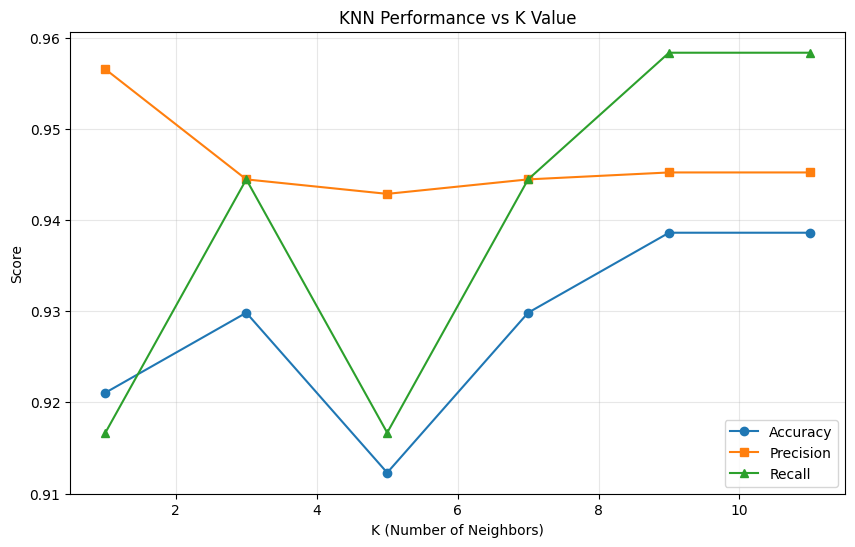

In [15]:
#Step 7

# Experiment with different K values
print("\n" + "="*50)
print("EXPERIMENTING WITH DIFFERENT K VALUES")
print("="*50)
 
k_values = [1, 3, 5, 7, 9, 11]
results = []
 
for k in k_values:
    # Create and train model
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    
    # Make predictions
    y_pred_temp = knn_temp.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred_temp)
    prec = precision_score(y_test, y_pred_temp)
    rec = recall_score(y_test, y_pred_temp)
    
    results.append({
        'K': k,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec
    })
    
    print(f"K={k:2d}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}")
 
# Find best K
results_df = pd.DataFrame(results)
best_k = results_df.loc[results_df['Accuracy'].idxmax(), 'K']
print(f"\nBest K value: {best_k} (Accuracy: {results_df['Accuracy'].max():.4f})")
 
# Visualize results
plt.figure(figsize=(10, 6))
plt.plot(results_df['K'], results_df['Accuracy'], marker='o', label='Accuracy')
plt.plot(results_df['K'], results_df['Precision'], marker='s', label='Precision')
plt.plot(results_df['K'], results_df['Recall'], marker='^', label='Recall')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Score')
plt.title('KNN Performance vs K Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('knn_k_comparison.png', dpi=150, bbox_inches='tight')
print("\nSaved visualization to 'knn_k_comparison.png'")
plt.show()

Best K = 9 with 93.86% accuracy. 
K=9 and K=11 give identical results, which means the model is stable at that range — adding more neighbors doesn't change anything.

K=1 is misleading — it has the highest precision (0.9565) but lower accuracy. That's because with only 1 neighbor, the model is very sensitive to individual data points (overfitting). One noisy sample can throw off the prediction.

K=5 was your starting point and it actually performed the worst here (91.23% accuracy). The dip at K=5 is interesting — sometimes certain K values just don't suit the data well.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# Load the data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Explore it
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nChurn distribution:\n{df['Churn'].value_counts()}")
df.head()

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
customerID      

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
# TotalCharges has some blank spaces that need fixing
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# Drop customerID - it's just an ID, not a useful feature
df = df.drop('customerID', axis=1)

# Convert Churn to 0/1
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Convert all other text columns to numbers
df = pd.get_dummies(df, drop_first=True)

In [18]:
# Scale the features first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Then train on scaled data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

print("KNN classifier trained successfully!")
print(f"Number of neighbors (k): {knn.n_neighbors}")

# Step 5 - Make predictions on scaled data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

print(f"\nTraining predictions: {len(y_train_pred)}")
print(f"Test predictions: {len(y_test_pred)}")

KNN classifier trained successfully!
Number of neighbors (k): 5

Training predictions: 455
Test predictions: 114


In [19]:
print(df.shape)
print(df.columns.tolist())

(7032, 31)
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [20]:
# Step 3 - Split
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Training: 5625, Test: 1407
